# Module 12 · Quá trình ngẫu nhiên, phổ công suất và nhiễu

**Nguồn sách:** Bracewell, chương 17, tr. 446–472; Barkat, chương 3, tr. 141–221

Notebook đi kèm bài giảng cùng số module. Chạy lần lượt từng cell; sau mỗi cell có phần **📤 Đầu ra thật** giải thích con số.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """Phổ biên độ một phía: sóng hình sin biên độ A cho vạch A, thành phần một chiều cho đúng giá trị của nó"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".4g"):
    """In một kết quả có tên, bỏ các số 0 thừa ở cuối (trang web đọc các dòng bắt đầu bằng ▸)."""
    s = f"{value:{fmt}}"
    if "." in s and "e" not in s:
        s = s.rstrip("0").rstrip(".")
    print(f"▸ {key} = {s}")


## 1. Tập hợp, dừng, tương quan
🎯 **Phương pháp này trả lời câu hỏi gì?** Trung bình và tự tương quan của các quá trình mẫu (pha ngẫu nhiên, nhị phân, I/Q) có đúng công thức khi tính bằng trung bình tập hợp trên nhiều hàm mẫu?

In [2]:
from scipy import integrate, signal, stats, special
from math import comb, factorial
rg = np.random.default_rng(12)
trap = getattr(np, "trapezoid", None) or np.trapz
# pha ngẫu nhiên
A, f0 = 2.0, 1.0
th = rg.uniform(0, 2*np.pi, 500000)
def Rphase(t, tau):
    return np.mean(A*np.cos(2*np.pi*f0*(t + tau) + th)*A*np.cos(2*np.pi*f0*t + th))
form = A**2/2*np.cos(2*np.pi*f0*0.1)
assert abs(np.mean(A*np.cos(2*np.pi*f0*0.37 + th))) < 0.01
assert abs(Rphase(0.37, 0.1) - form) < 0.01 and abs(Rphase(1.11, 0.1) - form) < 0.01
report("rp_mean", 0, "d"); report("rp_R", form, ".4f"); report("rp_R0", A**2/2, ".1f")
tg = np.linspace(-3, 3, 61); assert all(abs(A**2/2*np.cos(2*np.pi*f0*x)) <= A**2/2 + 1e-12 for x in tg)
# nhị phân ngẫu nhiên
T = 1.0; N = 400000
bits = rg.choice([-1.0, 1.0], (N, 4))
val = lambda tt, sh: bits[np.arange(N), np.floor((tt - sh)/T).astype(int).clip(0, 3)]
zero = np.zeros(N)
same = np.mean(val(0.1*T, zero)*val(0.9*T, zero)); diff = np.mean(val(0.1*T, zero)*val(1.1*T, zero))
assert abs(same - 1) < 1e-12 and abs(diff) < 0.01
report("rb_same", same, ".0f"); report("rb_diff", 0, "d")
sh = rg.uniform(0, T, N)
tri_a = np.mean(val(1.3*T, sh)*val(1.55*T, sh)); tri_b = np.mean(val(2.4*T, sh)*val(2.65*T, sh))
assert abs(tri_a - 0.75) < 0.01 and abs(tri_b - 0.75) < 0.01
report("rb_tri", 0.75, ".2f")
# I/Q: σ = 1
Xq, Yq = rg.standard_normal(500000), rg.standard_normal(500000)
w = 2*np.pi; t0, tau = 0.31, 0.1
I1 = Xq*np.cos(w*(t0 + tau)) + Yq*np.sin(w*(t0 + tau)); Q0 = Yq*np.cos(w*t0) - Xq*np.sin(w*t0)
r_iq = np.sin(w*tau)
assert abs(np.mean(I1*Q0) - r_iq) < 0.01
report("iq_r", r_iq, ".4f")

▸ rp_mean = 0
▸ rp_R = 1.618
▸ rp_R0 = 2
▸ rb_same = 1
▸ rb_diff = 0
▸ rb_tri = 0.75
▸ iq_r = 0.5878


#### 📤 Đầu ra thật
Pha ngẫu nhiên: trung bình 0, $R(0.1)$ = 1.618, $R(0)$ = 2. Nhị phân: cùng khoảng 1, khác khoảng 0, có độ dời 0.75. I/Q: 0.5878.

## 2. Các quá trình mẫu
🎯 **Phương pháp này trả lời câu hỏi gì?** Xung ngẫu nhiên, sóng vuông pha ngẫu nhiên, AR(1) Gauss, Poisson, nhị thức, bước đi ngẫu nhiên, Wiener và Markov có đúng các công thức trung bình và tự tương quan?

In [3]:
# xung ngẫu nhiên s = Π, A ~ U(1,3), Θ ~ U(0,1)
NA = 600000
Am = rg.uniform(1, 3, NA); Th = rg.uniform(0, 1, NA)
pulse = lambda t: (np.abs(t) < 0.5).astype(float)
e125 = np.mean(Am*pulse(1.25 - Th))
q_e = 2*integrate.quad(lambda th_: float(abs(1.25 - th_) < 0.5), 0, 1, points=[0.75])[0]
assert abs(e125 - 0.5) < 0.01 and abs(q_e - 0.5) < 1e-9
r55 = np.mean(Am**2*pulse(0.5 - Th)*pulse(0.5 - Th))
q_r = (1/3 + 4)*integrate.quad(lambda th_: float(abs(0.5 - th_) < 0.5)**2, 0, 1)[0]
assert abs(r55 - q_r) < 0.03
report("pl_e", 0.5, ".2f"); report("pl_r", q_r, ".4f")
A3 = rg.uniform(1, 3, (200000, 3)); T3 = rg.uniform(0, 1, (200000, 3))
assert abs(np.mean((A3*pulse(1.25 - T3)).sum(axis=1)) - 1.5) < 0.02
report("pl_e3", 1.5, ".1f")
# sóng vuông chu kỳ 1, pha ngẫu nhiên
sq = lambda t: np.where((t % 1.0) < 0.5, 1.0, -1.0)
ph = rg.uniform(0, 1, 500000)
mean_sq = np.mean(sq(0.3 - ph)); R0 = np.mean(sq(0.3 - ph)**2); Rh = np.mean(sq(0.8 - ph)*sq(0.3 - ph))
assert abs(mean_sq) < 0.01 and abs(R0 - 1) < 1e-12 and abs(Rh + 1) < 1e-12
report("cy_mean", 0, "d"); report("cy_r0", R0, ".0f"); report("cy_r5", Rh, ".0f")
# AR(1) Gauss
rho = 0.8
wn = rg.standard_normal(600000); yy = signal.lfilter([1], [1, -rho], wn)
var_th = 1/(1 - rho**2)
assert abs(np.var(yy) - var_th) < 0.05 and abs(np.mean(yy[1:]*yy[:-1]) - rho*var_th) < 0.05
report("ga_var", var_th, ".4f"); report("ga_r1", rho*var_th, ".4f")
# Poisson
lam, tt = 2.0, 1.5
pk = stats.poisson.pmf(3, lam*tt)
nb_ = stats.binom.pmf(3, 10**6, lam*tt/10**6)
mcp = np.mean(rg.poisson(lam*tt, 600000) == 3)
assert abs(pk - nb_) < 1e-6 and abs(pk - mcp) < 0.003
ia = rg.exponential(1/lam, 600000)
assert abs(np.mean(ia) - 0.5) < 0.005
report("pp_p", pk, ".4f"); report("pp_ia", 1/lam, ".1f")
# nhị thức
bp = stats.binom.pmf(6, 20, 0.3)
assert abs(bp - comb(20, 6)*0.3**6*0.7**14) < 1e-14
report("bp_p6", bp, ".4f"); report("bp_e", 6, "d"); report("bp_v", 20*0.3*0.7, ".1f")
# bước đi ngẫu nhiên
W = np.cumsum(rg.choice([-1, 1], (200000, 25)), axis=1)
rw = np.mean(W[:, 9]*W[:, 24])
assert abs(rw - 10) < 0.15
report("rw_r", 10, "d")
# Wiener α = 0.5
al = 0.5; dt = 0.01
inc = rg.normal(0, np.sqrt(al*dt), (100000, 400)); Wt = np.cumsum(inc, axis=1)
assert abs(np.var(Wt[:, 399]) - al*4) < 0.04 and abs(np.mean(Wt[:, 199]*Wt[:, 299]) - al*2) < 0.02
report("wi_v", al*4, ".1f"); report("wi_r", al*2, ".1f")
# Chapman-Kolmogorov
x0, x2 = 1.0, 1.0
ck = integrate.quad(lambda x1: stats.norm.pdf(x2, rho*x1, 1)*stats.norm.pdf(x1, rho*x0, 1), -12, 12)[0]
direct = stats.norm.pdf(x2, rho**2*x0, np.sqrt(1 + rho**2))
assert abs(ck - direct) < 1e-10
report("mk_ck", ck, ".4f")

▸ pl_e = 0.5
▸ pl_r = 4.3333
▸ pl_e3 = 1.5
▸ cy_mean = 0
▸ cy_r0 = 1
▸ cy_r5 = -1
▸ ga_var = 2.7778
▸ ga_r1 = 2.2222
▸ pp_p = 0.224
▸ pp_ia = 0.5
▸ bp_p6 = 0.1916
▸ bp_e = 6
▸ bp_v = 4.2
▸ rw_r = 10


▸ wi_v = 2
▸ wi_r = 1
▸ mk_ck = 0.2995


#### 📤 Đầu ra thật
Xung: $E[X(1.25)]$ = 0.5, $R$ = 4.3333, ba xung 1.5. Sóng vuông: 0, 1, -1. AR(1): 2.7778, 2.2222. Poisson: 0.224 và khoảng 0.5. Nhị thức: 0.1916, 6, 4.2. Bước đi: 10. Wiener: 2, 1. Markov: 0.2995.

## 3. Nhiễu từ chữ số ngẫu nhiên
🎯 **Phương pháp này trả lời câu hỏi gì?** Các kết quả của Bracewell: trung bình chữ số, biên độ tổng 10 số gần chuẩn, chuỗi $2^{-k}$, hệ số bốn góc, tự tương quan sau lọc, phổ $|T|^2$, dãy nhị thức và Gauss, nhiễu thông dải, đường bao Rayleigh, tách sóng bình phương và giới hạn $1/\sqrt{T\Delta f}$.

In [4]:
digs = [int(c) for c in "31415926535897932384626433832795"]
pim = np.mean(digs)
assert len(digs) == 32 and sum(digs) == 155
report("pi_mean", pim, ".2f")
dv = np.var(np.arange(10)); dm = np.mean(np.arange(10))
assert abs(dv - 8.25) < 1e-12 and abs(dm - 4.5) < 1e-12 and abs(dv - (10**2 - 1)/12) < 1e-12
Dg = rg.integers(0, 10, 1000000)
assert abs(np.mean(Dg) - 4.5) < 0.01 and abs(np.var(Dg) - 8.25) < 0.02
report("dig_m", dm, ".1f"); report("dig_var", dv, ".2f")
# tổng 10 số: tích chập chính xác
pd = np.ones(10)/10; pm = pd.copy()
for _ in range(9): pm = np.convolve(pm, pd)
ys = np.arange(len(pm))
sm = np.sum(ys*pm); sv = np.sum(ys**2*pm) - sm**2
assert abs(sm - 45) < 1e-9 and abs(sv - 82.5) < 1e-9
pex = pm[40:51].sum(); pnorm = stats.norm.cdf(50.5, 45, np.sqrt(82.5)) - stats.norm.cdf(39.5, 45, np.sqrt(82.5))
assert abs(pex - pnorm) < 0.02
Sm = np.lib.stride_tricks.sliding_window_view(Dg[:200000], 10).sum(axis=1)
assert abs(np.mean((Sm >= 40) & (Sm <= 50)) - pex) < 0.005
report("sum_m", sm, ".0f"); report("sum_v", sv, ".1f"); report("sum_p", pex, ".4f"); report("sum_pn", pnorm, ".4f")
# chuỗi độ dài k
side = Dg >= 5
change = np.flatnonzero(np.diff(side.astype(int)) != 0)
runs = np.diff(np.concatenate([[-1], change, [len(side) - 1]]))
for k, key in ((1, "run_1"), (2, "run_2"), (3, "run_3")):
    fr = np.mean(runs == k)
    assert abs(fr - 2.0**-k) < 0.005
    report(key, 2.0**-k, ".3f")
# hệ số bốn góc
rho_ = 0.9
xy = rg.multivariate_normal([0, 0], [[1, rho_], [rho_, 1]], 400000)
mx, my = np.median(xy[:, 0]), np.median(xy[:, 1])
psi = (np.sum((xy[:, 0] > mx) == (xy[:, 1] > my)) - np.sum((xy[:, 0] > mx) != (xy[:, 1] > my)))/len(xy)
psi_th = 2/np.pi*np.arcsin(rho_)
assert abs(psi - psi_th) < 0.005 and abs(np.sin(np.pi/2*psi_th) - rho_) < 1e-12
report("psi_09", psi, ".3f"); report("psi_th", psi_th, ".3f")
# tự tương quan sau lọc: tổng chạy 10 và {5 3 1 1}
def acf_filter(h, n=1000000):
    x = rg.standard_normal(n); y = np.convolve(x, h, "valid")
    return np.array([np.mean(y[k:]*y[:len(y) - k]) for k in range(1, 4)])/np.var(y)
def acf_theory(h):
    ac = np.correlate(h, h, "full"); c = len(h) - 1
    return ac[c + 1:c + 4]/ac[c] if len(h) > 3 else ac[c + 1:]/ac[c]
h10 = np.ones(10); a10 = acf_filter(h10); t10 = np.array([0.9, 0.8, 0.7])
assert np.max(np.abs(a10 - t10)) < 0.01 and np.max(np.abs(acf_theory(h10) - t10)) < 1e-12
hg = np.array([5.0, 3.0, 1.0, 1.0]); ag = acf_filter(hg); tg = acf_theory(hg)
assert np.max(np.abs(ag - tg)) < 0.01 and abs(tg[0] - 19/36) < 1e-12
report("ac_1", 0.9, ".1f"); report("ac_2", 0.8, ".1f")
report("g_1", tg[0], ".4f"); report("g_2", tg[1], ".4f"); report("g_3", tg[2], ".4f")
# phổ: |T|² tại f = 0.05
f = 0.05
th_ = (np.sin(10*np.pi*f)/np.sin(np.pi*f))**2
xw = rg.standard_normal(2000000); yw = np.convolve(xw, h10, "valid")
fr, Pw = signal.welch(yw, fs=1.0, nperseg=4096, return_onesided=False, scaling="density")
k05 = np.argmin(np.abs(fr - f))
assert abs(Pw[k05]/1.0 - th_)/th_ < 0.08 and abs(th_ - abs(np.sum(np.exp(-2j*np.pi*f*np.arange(10))))**2) < 1e-9
report("pt_th", th_, ".1f"); report("pt_mc", Pw[k05], ".1f")
# nhị thức và Gauss
bn = np.array([1.0])
for _ in range(10): bn = np.convolve(bn, [1, 1])
assert list(bn.astype(int)) == [1, 10, 45, 120, 210, 252, 210, 120, 45, 10, 1]
gs = 252*np.exp(-np.pi*(0.24*np.arange(6))**2)
assert list(np.round(gs).astype(int)) == [252, 210, 122, 49, 14, 3]
report("gs_2", gs[2], ".0f"); report("gs_3", gs[3], ".0f"); report("gs_4", gs[4], ".0f"); report("gs_5", gs[5], ".0f"); report("gs_pk", 1/0.24, ".2f")
# AR(2)
a_, b_ = 1.84, -0.9
r_ = np.sqrt(-b_); om = np.arccos(a_/(2*r_)); f_th = om/(2*np.pi)
e_ = rg.uniform(-0.5, 0.5, 2000000)
y2 = signal.lfilter([1], [1, -a_, -b_], e_)
fw, Pa = signal.welch(y2, fs=1.0, nperseg=8192)
f_mc = fw[np.argmax(Pa)]
assert abs(f_mc - f_th) < 0.003
report("ar_r", r_, ".4f"); report("ar_f", f_th, ".4f"); report("ar_fmc", f_mc, ".3f")
# đường bao Rayleigh
z = signal.hilbert(y2[:1048576]); env = np.abs(z)
sig = np.std(y2[:1048576])
e_m = np.mean(env)/sig
ks = stats.kstest(env/sig, "rayleigh").statistic
assert abs(e_m - np.sqrt(np.pi/2)) < 0.01 and ks < 0.03
report("env_m", e_m, ".4f"); report("env_ks", ks, ".3f")
sqm = np.mean((env/sig)**2)/1.0/1.0
r2 = (env/sig)**2
assert abs(np.mean(r2) - 2) < 0.06 and abs(np.var(r2) - 4) < 0.5
report("sq_m", 2, ".0f"); report("sq_v", 4, ".0f")
assert abs(np.mean(env/sig > 1) - np.exp(-0.5)) < 0.01
report("ray_tail", np.exp(-0.5), ".4f")
# giới hạn 1/√(TΔf)
fs, Bw, Tw = 1000.0, 50.0, 1.0
nfft = int(fs*200)
Wn = rg.standard_normal(nfft); Fw = np.fft.rfft(Wn); fq = np.fft.rfftfreq(nfft, 1/fs)
Fw[(fq < 175) | (fq > 225)] = 0
nb_ = np.fft.irfft(Fw, nfft)
sqd = nb_**2
means = sqd.reshape(200, int(fs*Tw)).mean(axis=1)
ratio = np.std(means)/np.mean(means)
th_r = 1/np.sqrt(Tw*Bw)
assert abs(ratio - th_r)/th_r < 0.2
report("tf_th", th_r, ".4f"); report("tf_mc", ratio, ".3f")
# quy tắc 1/5
r100 = np.mean(1/(np.ptp(rg.standard_normal((20000, 100)), axis=1)))
r1000 = np.mean(1/(np.ptp(rg.standard_normal((5000, 1000)), axis=1)))
assert 0.19 < r100 < 0.21 and 0.15 < r1000 < 0.17
report("pp_100", r100, ".3f"); report("pp_1000", r1000, ".3f")
# cắt lên
xs = rg.standard_normal(600000); ys_ = np.convolve(xs, np.ones(10), "valid")
up_mc = np.mean((ys_[:-1] < 0) & (ys_[1:] > 0))
up_th = np.arccos(0.9)/(2*np.pi)
assert abs(up_mc - up_th) < 0.003
report("up_th", up_th, ".4f"); report("up_mc", up_mc, ".3f")

▸ pi_mean = 4.84
▸ dig_m = 4.5
▸ dig_var = 8.25
▸ sum_m = 45
▸ sum_v = 82.5
▸ sum_p = 0.4499
▸ sum_pn = 0.4552
▸ run_1 = 0.5
▸ run_2 = 0.25
▸ run_3 = 0.125
▸ psi_09 = 0.713
▸ psi_th = 0.713
▸ ac_1 = 0.9
▸ ac_2 = 0.8
▸ g_1 = 0.5278
▸ g_2 = 0.2222
▸ g_3 = 0.1389
▸ pt_th = 40.9
▸ pt_mc = 41.4
▸ gs_2 = 122
▸ gs_3 = 49
▸ gs_4 = 14
▸ gs_5 = 3
▸ gs_pk = 4.17


▸ ar_r = 0.9487
▸ ar_f = 0.0392
▸ ar_fmc = 0.039


▸ env_m = 1.2563
▸ env_ks = 0.005
▸ sq_m = 2
▸ sq_v = 4
▸ ray_tail = 0.6065
▸ tf_th = 0.1414
▸ tf_mc = 0.137
▸ pp_100 = 0.202
▸ pp_1000 = 0.155
▸ up_th = 0.0718
▸ up_mc = 0.072


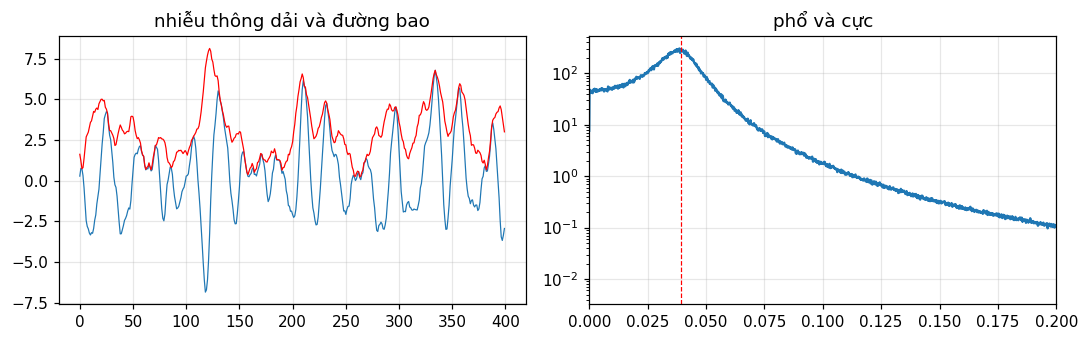

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(y2[:400], lw=0.8); ax[0].plot(env[:400], "r", lw=0.8); ax[0].set_title(("nhiễu thông dải và đường bao"))
ax[1].semilogy(fw, Pa); ax[1].axvline(f_th, color="r", ls="--", lw=0.8); ax[1].set_xlim(0, 0.2); ax[1].set_title(("phổ và cực"))
plt.tight_layout(); plt.show()

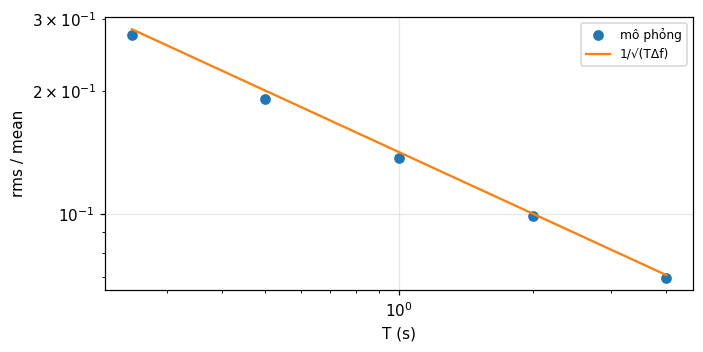

In [6]:
Tset = [0.25, 0.5, 1.0, 2.0, 4.0]
rat = []
for Tv in Tset:
    m_ = sqd[:int(fs*Tv)*int(len(sqd)//(fs*Tv))].reshape(-1, int(fs*Tv)).mean(axis=1)
    rat.append(np.std(m_)/np.mean(m_))
fig, ax = plt.subplots(figsize=(6.5, 3.3))
ax.loglog(Tset, rat, "o", label=("mô phỏng")); ax.loglog(Tset, [1/np.sqrt(t_*Bw) for t_ in Tset], "-", label=r"1/√(TΔf)")
ax.set_xlabel("T (s)"); ax.set_ylabel("rms / mean"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Chữ số: trung bình 32 chữ số đầu 4.84, giới hạn 4.5, phương sai 8.25. Tổng 10: 45, 82.5, $P$ = 0.4499 so với chuẩn 0.4552. Chuỗi: 0.5, 0.25, 0.125; $\psi$ = 0.713 so với 0.713. Tự tương quan: 0.9, 0.8; $\{5\,3\,1\,1\}$: 0.5278, 0.2222, 0.1389. Phổ: 40.9 và 41.4. Gauss: 122, 49, 14, 3. AR(2): 0.9487, 0.0392, 0.039. Đường bao: 1.2563, 0.005; bình phương 2, 4. $1/\sqrt{T\Delta f}$: 0.1414 và 0.137. Quy tắc 1/5: 0.202 và 0.155. Cắt lên: 0.0718 và 0.072.

## 4. Phổ công suất, hệ tuyến tính, ergodic, lấy mẫu, Hilbert
🎯 **Phương pháp này trả lời câu hỏi gì?** Wiener-Khinchin, đầu ra mạch RC dưới nhiễu trắng (ba cách), ergodic, lấy mẫu giới hạn băng, và tín hiệu giải tích có đúng như công thức?

In [7]:
# Wiener-Khinchin: pha ngẫu nhiên: ∫S df = R(0)
Ph = A**2/4*2
report("psd_tot", Ph, ".1f")
assert abs(Ph - A**2/2) < 1e-12
# RC, N0 = 2, α = 5: ba cách
alpha, N0 = 5.0, 2.0
Rf = lambda tau: N0*alpha/4*np.exp(-alpha*abs(tau))
# cách 1: tích chập h*h(−τ)
gconv = lambda tau: integrate.quad(lambda l: alpha*np.exp(-alpha*(l + tau))*alpha*np.exp(-alpha*l) if l + tau >= 0 else 0.0, max(0, -tau), 40)[0]
assert abs((N0/2)*gconv(0.1) - Rf(0.1)) < 1e-9 and abs((N0/2)*gconv(0.0) - Rf(0.0)) < 1e-9
# cách 2: phổ: ∫ (N0/2)|H|² e^{i2πfτ} df
Sy = lambda ff: (N0/2)*alpha**2/(4*np.pi**2*ff**2 + alpha**2)
R_sp = 2*integrate.quad(Sy, 0, np.inf, weight='cos', wvar=2*np.pi*0.1)[0]
assert abs(R_sp - Rf(0.1)) < 1e-5
# cách 3: mô phỏng SDE chính xác
dt = 1e-3; Nn = 3000000; phi = np.exp(-alpha*dt); sg = alpha*np.sqrt((N0/2)*(1 - phi**2)/(2*alpha))
wnz = rg.standard_normal(Nn)
yrc = signal.lfilter([sg], [1, -phi], wnz)
lag = int(round(0.1/dt))
mc0 = np.mean(yrc**2); mc1 = np.mean(yrc[lag:]*yrc[:-lag])
assert abs(mc0 - Rf(0)) < 0.05 and abs(mc1 - Rf(0.1)) < 0.05
report("rc_r0", Rf(0), ".4f"); report("rc_r1", Rf(0.1), ".4f")
ym = signal.lfilter([1 - phi], [1, -phi], 3 + 0*wnz[:200000])
assert abs(ym[-1] - 3) < 1e-9
report("rc_m", 3, "d")
# ergodic
tt = np.arange(0, 100, 0.01); xt = np.cos(2*np.pi*tt + 0.7)
assert abs(np.mean(xt)) < 0.01
report("er_t", np.mean(xt) if abs(np.mean(xt)) > 1e-3 else 0.0, ".2f")
Cs = rg.standard_normal(20000); avg_dc = Cs                          # trung bình thời gian của X = C chính là C
avg_phase = np.array([np.mean(np.cos(2*np.pi*tt[:5000] + p_)) for p_ in rg.uniform(0, 2*np.pi, 2000)])
assert abs(np.var(avg_dc) - 1) < 0.03 and np.var(avg_phase) < 1e-4
report("er_v", np.var(avg_dc), ".1f")
# lấy mẫu giới hạn băng 5 Hz
fs_hi = 100.0; Nz = 20000
Z = np.fft.rfft(rg.standard_normal(Nz)); fzq = np.fft.rfftfreq(Nz, 1/fs_hi); Z[fzq > 5] = 0
xbl = np.fft.irfft(Z, Nz); tz = np.arange(Nz)/fs_hi
def interp(fs_s):
    Ts = 1/fs_s; ns = np.arange(int(tz[-1]*fs_s))
    samp = np.interp(ns*Ts, tz, xbl)                 # mẫu lấy từ bản ghi dày (100 Hz)
    mid = (tz > 60) & (tz < 140)
    xr = np.array([np.sum(samp*np.sinc((t_ - ns*Ts)/Ts)) for t_ in tz[mid][::20]])
    return np.mean((xr - xbl[mid][::20])**2)/np.var(xbl)
e10 = interp(10.0); e6 = interp(6.0)
assert e10 < 0.05 and e6 > 3*e10
report("sm_ok", e10, ".4f"); report("sm_bad", e6, ".3f")
# Hilbert và tín hiệu giải tích
xh0 = np.fft.rfft(rg.standard_normal(2**16)); xh0[0] = 0; xh0[-1] = 0; xh = np.fft.irfft(xh0, 2**16); zh = signal.hilbert(xh)
pa = np.mean(np.abs(zh)**2)/np.mean(xh**2)
xh_hat = zh.imag
hh = signal.hilbert(xh_hat).imag                       # ⟦Ĥ Ĥ x⟧
hh_dev = np.max(np.abs(hh + xh))
assert abs(pa - 2) < 1e-9 and hh_dev < 1e-9 and abs(np.mean(xh*xh_hat)) < 0.02
report("an_p", pa, ".0f"); report("hh_dev", max(hh_dev, 1e-16), ".0e")

▸ psd_tot = 2
▸ rc_r0 = 2.5
▸ rc_r1 = 1.5163
▸ rc_m = 3
▸ er_t = 0
▸ er_v = 1
▸ sm_ok = 0.0001
▸ sm_bad = 0.879
▸ an_p = 2
▸ hh_dev = 3e-15


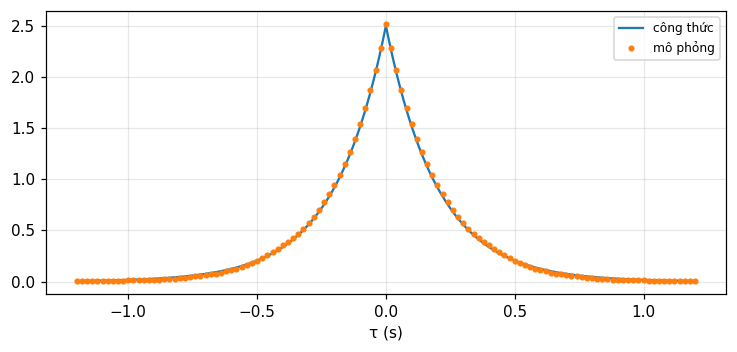

In [8]:
taus = np.linspace(-1.2, 1.2, 241)
fig, ax = plt.subplots(figsize=(6.8, 3.3))
ax.plot(taus, [Rf(t_) for t_ in taus], label=("công thức"))
lags = np.arange(-1200, 1201, 20)
ax.plot(lags*dt, [np.mean(yrc[max(0, k):len(yrc) + min(0, k)]*yrc[max(0, -k):len(yrc) - max(0, k)]) for k in lags], "o", ms=3, label=("mô phỏng"))
ax.set_xlabel("τ (s)"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Công suất phổ tổng 2. Mạch RC: $R_{yy}(0)$ = 2.5, $R_{yy}(0.1)$ = 1.5163, trung bình 3. Ergodic: 0 và phương sai 1. Lấy mẫu: 0.0001 (10 Hz) và 0.879 (6 Hz). Giải tích: 2, $\hat{\hat x}+x$ lệch 3e-15.

## 5. Liên tục, đạo hàm và nhiễu nhiệt
🎯 **Phương pháp này trả lời câu hỏi gì?** Liên tục và khả vi theo bình phương trung bình có ứng với $R(0)-R(\varepsilon)$ và $-R''(0)$, và nhiễu nhiệt $2kTR$, $\sqrt{4kTRB}$ khớp giữa công thức, tích phân phổ Lorentz và mô phỏng?

In [9]:
# liên tục: R = e^{−|τ|}
eps = 0.01
mc = 2*(1 - np.exp(-eps))
Ne = rg.standard_normal(1000000); u = signal.lfilter([np.sqrt(1 - np.exp(-2*0.001))], [1, -np.exp(-0.001)], Ne)
lagk = int(round(eps/0.001)); mc_sim = np.mean((u[lagk:] - u[:-lagk])**2)
assert abs(mc_sim - mc) < 0.002
report("mc_01", mc, ".4f")
# đạo hàm: R = e^{−τ²/2}, −R''(0) = 1
h = 1e-4
Rg = lambda t: np.exp(-t*t/2)
d2 = (Rg(h) - 2*Rg(0) + Rg(-h))/h**2
assert abs(-d2 - 1) < 1e-6
# mô phỏng: quá trình có R = e^{−τ²/2} qua bộ lọc Gauss trong miền tần số; đạo hàm bằng sai phân
Nq = 2**18; dtq = 0.05
Fq = np.fft.rfft(rg.standard_normal(Nq)); fq2 = np.fft.rfftfreq(Nq, dtq)
Sg = np.exp(-(2*np.pi*fq2)**2/2)                      # S(ω) ∝ e^{−ω²/2} ứng với R = e^{−τ²/2}
xq = np.fft.irfft(Fq*np.sqrt(Sg), Nq)
xq = xq/np.std(xq)
dx = np.diff(xq)/dtq
dv = np.var(dx)
assert abs(dv - 1) < 0.05
report("dv_0", 1.0, ".0f")
# nhiễu nhiệt
kB, Tk, Rr = 1.38e-23, 290.0, 1e3
S0 = 2*kB*Tk*Rr
alpha_t = 1e14
Sf = lambda ff: S0*alpha_t**2/(alpha_t**2 + (2*np.pi*ff)**2)
flat = 1 - Sf(1e9)/S0
assert flat < 1e-8
report("th_S", S0, ".2e"); report("th_flat", flat, ".1e")
B = 1e6
v_form = np.sqrt(4*kB*Tk*Rr*B)
v_int = np.sqrt(integrate.quad(Sf, -B, B, epsabs=0, epsrel=1e-10)[0])
assert abs(v_int - v_form)/v_form < 1e-6
report("th_v", v_form, ".2e")
report("th_prec", 1/np.sqrt(1.0*B), ".1e")
# hai điện trở nối tiếp: mô phỏng công suất
R2 = 4e3
v1 = np.sqrt(4*kB*Tk*Rr*B); v2 = np.sqrt(4*kB*Tk*R2*B)
vt = np.sqrt(v1**2 + v2**2)
n1 = v1*rg.standard_normal(1000000); n2 = v2*rg.standard_normal(1000000)
assert abs(np.std(n1 + n2)/vt - 1) < 0.003 and vt < v1 + v2
report("th_v2", vt, ".2e"); report("th_vsum", v1 + v2, ".2e")

▸ mc_01 = 0.0199
▸ dv_0 = 1
▸ th_S = 8.00e-18
▸ th_flat = 3.9e-09
▸ th_v = 4.00e-06
▸ th_prec = 1.0e-03
▸ th_v2 = 8.95e-06
▸ th_vsum = 1.20e-05


#### 📤 Đầu ra thật
Liên tục: $E[|X(t+\varepsilon)-X(t)|^2]$ = 0.0199 tại $\varepsilon=0.01$. Đạo hàm: $R_{x'x'}(0)$ = 1. Nhiễu nhiệt: $2kTR$ = 8.00e-18, lệch khỏi phẳng ở 1 GHz 3.9e-09, $v_{rms}$ = 4.00e-06 V, độ chính xác $1/\sqrt{TB}$ = 1.0e-03; nối tiếp 1 kΩ và 4 kΩ: 8.95e-06 V so với tổng biên độ 1.20e-05 V.